In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('./data/titanic_clean.csv')

In [3]:
df.sample(4)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
568,0,3,male,28.0,0,0,7.2292,C
732,0,2,male,28.0,0,0,0.0000,S
660,1,1,male,50.0,2,0,133.6500,S
261,1,3,male,3.0,4,2,31.3875,S


In [4]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

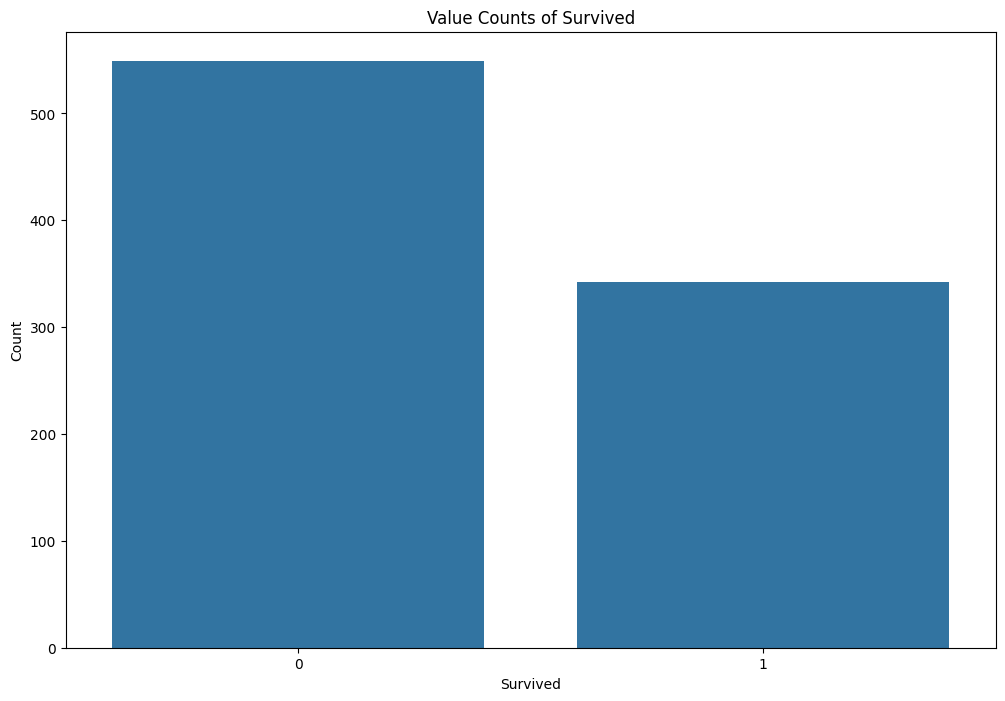

In [5]:
plt.figure(figsize=(12, 8))

sns.barplot(x = df['Survived'].value_counts().index, y = df['Survived'].value_counts())
plt.title('Value Counts of Survived')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

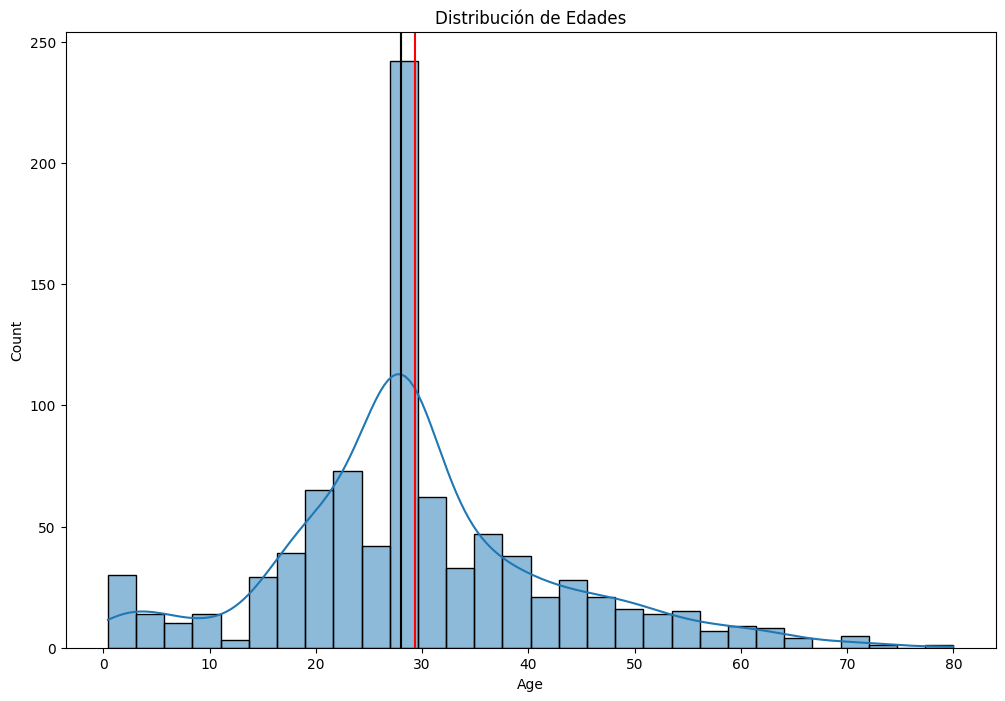

Media: 29.36158249158249
Mediana: 28.0
Moda: 28.0


In [6]:
plt.figure(figsize = (12, 8))

sns.histplot(df, x = 'Age', kde = True)
plt.title('Distribución de Edades')
plt.axvline(df['Age'].mean(), color = 'red')
plt.axvline(df['Age'].median(), color = 'green')
plt.axvline(df['Age'].mode()[0], color = 'black')
plt.show()

# Print the results
print(f"Media: {df['Age'].mean()}")
print(f"Mediana: {df['Age'].median()}")
print(f"Moda: {df['Age'].mode()[0]}")

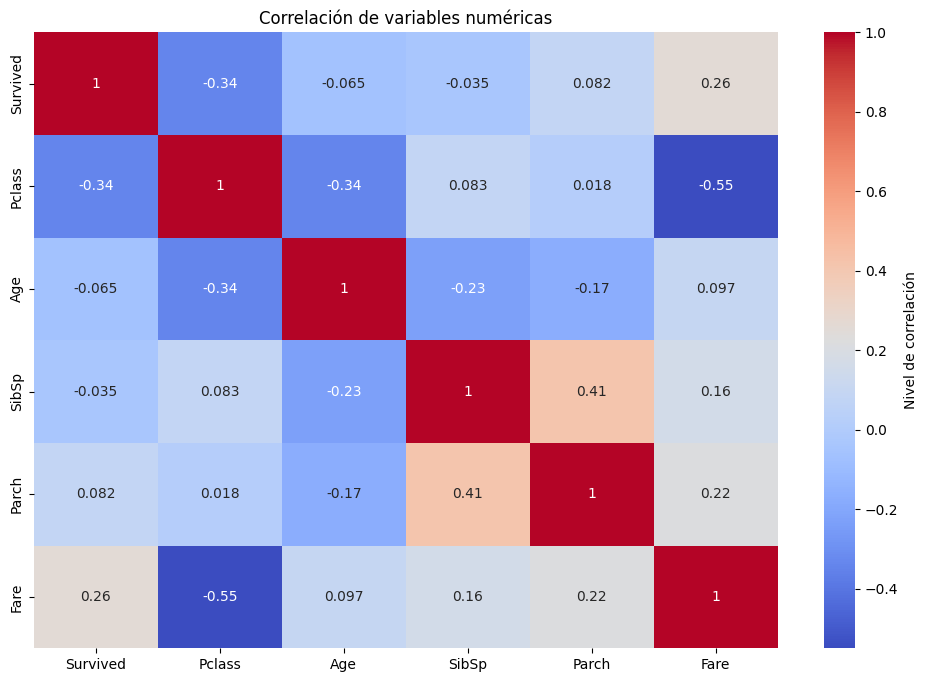

In [7]:
plt.figure(figsize = (12, 8))
sns.heatmap(df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].corr(), 
            annot=True, 
            cbar=True,  # Activar la barra de colores
            cmap='coolwarm',  # Cambiar la paleta de colores
            cbar_kws={'label': 'Nivel de correlación'})  # Etiqueta para la barra de colores
plt.title('Correlación de variables numéricas')
plt.show()

## Ejercicios EDA solicitados

> A continuación, cada bloque incluye una **nota de instrucción** arriba del código correspondiente.

In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style='whitegrid', palette='deep')

# Si df no está definido en el entorno, intentamos cargarlo.
if 'df' not in globals():
    try:
        df = pd.read_csv('data/titanic_clean.csv')
    except FileNotFoundError:
        df = pd.read_csv('data/titanic.csv')

# Aseguramos tipos numéricos para columnas relevantes.
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Fare'] = pd.to_numeric(df['Fare'], errors='coerce')
df['SibSp'] = pd.to_numeric(df['SibSp'], errors='coerce')
df['Survived'] = pd.to_numeric(df['Survived'], errors='coerce')

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


### Instrucción 1
Crear una gráfica que muestre la distribución de edades de los pasajeros.

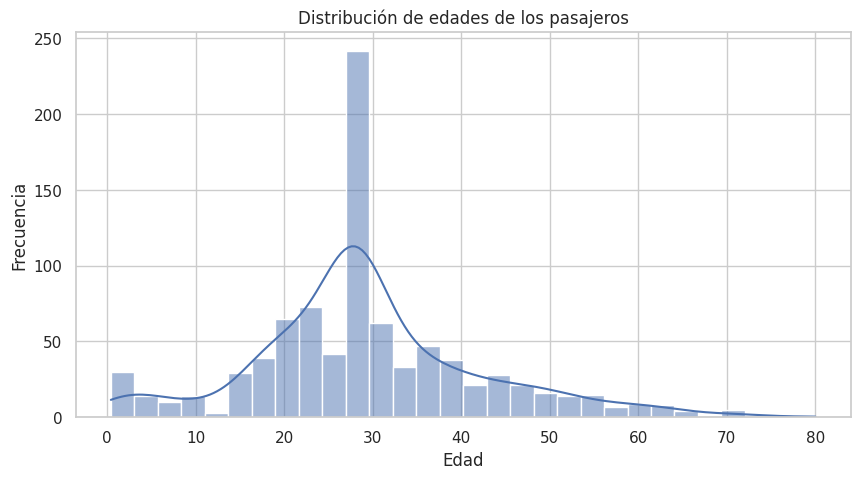

In [9]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Age'].dropna(), bins=30, kde=True)
plt.title('Distribución de edades de los pasajeros')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

### Instrucciones 2, 3 y 4
- Cantidad de sobrevivientes por clase (`Pclass`).
- Cantidad de sobrevivientes por género (`Sex`).
- Cantidad de sobrevivientes por puerto de embarque (`Embarked`).

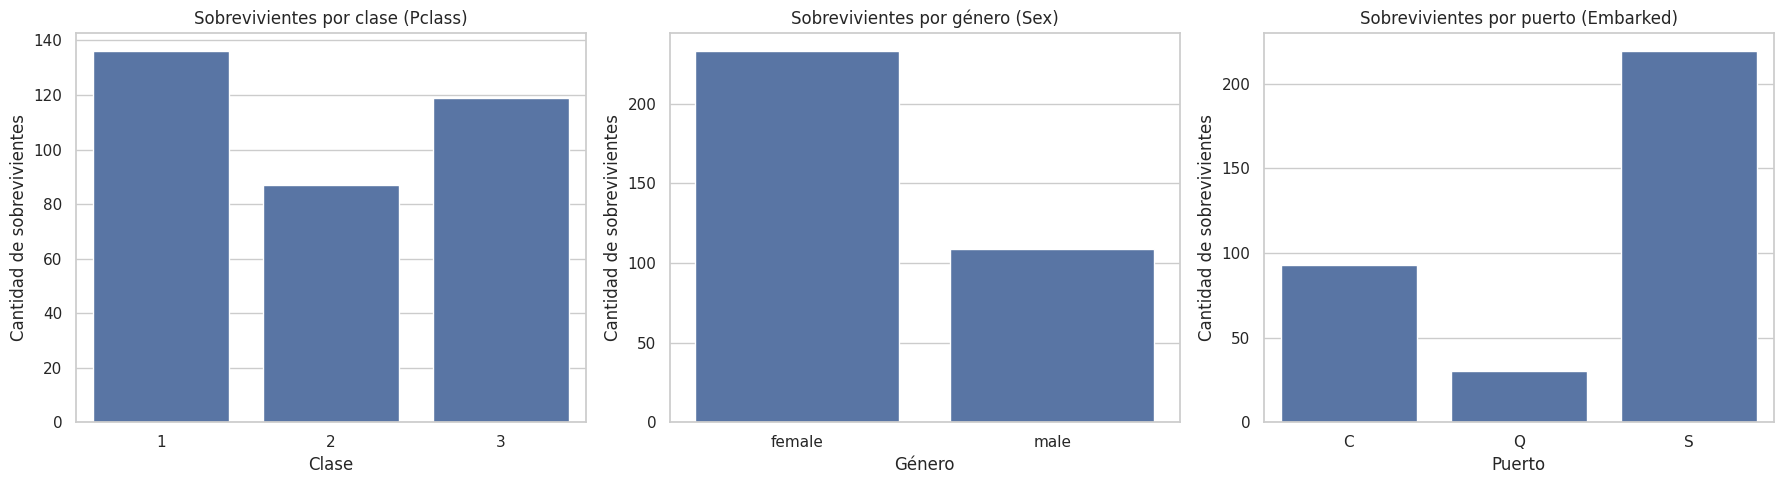

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df[df['Survived'] == 1], x='Pclass', ax=axes[0])
axes[0].set_title('Sobrevivientes por clase (Pclass)')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Cantidad de sobrevivientes')

sns.countplot(data=df[df['Survived'] == 1], x='Sex', ax=axes[1])
axes[1].set_title('Sobrevivientes por género (Sex)')
axes[1].set_xlabel('Género')
axes[1].set_ylabel('Cantidad de sobrevivientes')

sns.countplot(data=df[df['Survived'] == 1], x='Embarked', ax=axes[2], order=['C', 'Q', 'S'])
axes[2].set_title('Sobrevivientes por puerto (Embarked)')
axes[2].set_xlabel('Puerto')
axes[2].set_ylabel('Cantidad de sobrevivientes')

plt.tight_layout()
plt.show()

### Instrucción 5
Agrupar edades en categorías (Infante, Niño, Adolescente, Joven Adulto, Adulto, Mayor) y mostrar la **tasa de supervivencia** por grupo.

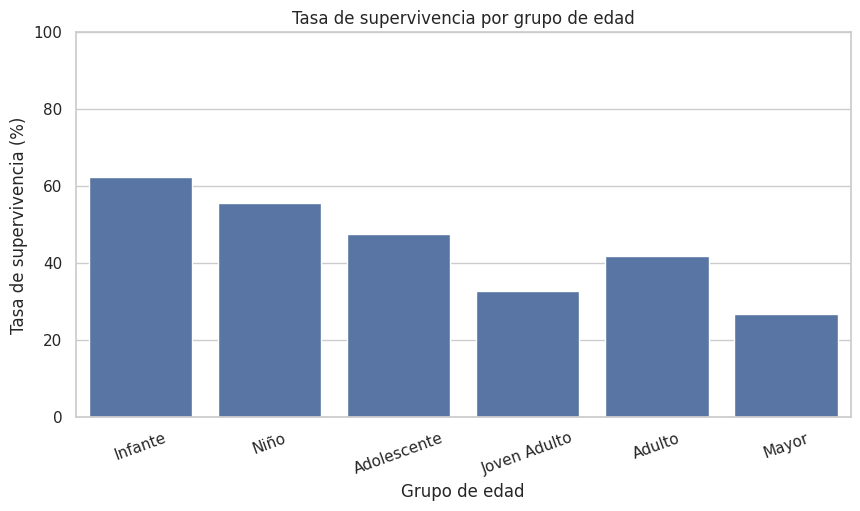

AgeGroup
Infante         62.500000
Niño            55.555556
Adolescente     47.727273
Joven Adulto    32.812500
Adulto          41.776316
Mayor           26.923077
Name: Survived, dtype: float64

In [11]:
bins = [0, 2, 12, 17, 29, 59, np.inf]
labels = ['Infante', 'Niño', 'Adolescente', 'Joven Adulto', 'Adulto', 'Mayor']

df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, include_lowest=True)
agegroup_survival_rate = df.groupby('AgeGroup', observed=False)['Survived'].mean().sort_index() * 100

plt.figure(figsize=(10, 5))
sns.barplot(x=agegroup_survival_rate.index, y=agegroup_survival_rate.values)
plt.title('Tasa de supervivencia por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Tasa de supervivencia (%)')
plt.xticks(rotation=20)
plt.ylim(0, 100)
plt.show()

agegroup_survival_rate

### Instrucciones 6, 7, 8 y 9
- Conteo de pasajeros por clase (`Pclass`).
- Distribución de género dentro de cada clase.
- Distribución de clase por puerto (`Embarked`).
- Conteo de pasajeros por género (`Sex`).

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.countplot(data=df, x='Pclass', ax=axes[0, 0])
axes[0, 0].set_title('Conteo de pasajeros por clase (Pclass)')
axes[0, 0].set_xlabel('Clase')
axes[0, 0].set_ylabel('Cantidad')

sns.countplot(data=df, x='Pclass', hue='Sex', ax=axes[0, 1])
axes[0, 1].set_title('Distribución de género dentro de cada clase')
axes[0, 1].set_xlabel('Clase')
axes[0, 1].set_ylabel('Cantidad')
axes[0, 1].legend(title='Sex')

sns.countplot(data=df, x='Embarked', hue='Pclass', order=['C', 'Q', 'S'], ax=axes[1, 0])
axes[1, 0].set_title('Distribución de clase por puerto (Embarked)')
axes[1, 0].set_xlabel('Puerto')
axes[1, 0].set_ylabel('Cantidad')
axes[1, 0].legend(title='Pclass')

sns.countplot(data=df, x='Sex', ax=axes[1, 1])
axes[1, 1].set_title('Conteo de pasajeros por género (Sex)')
axes[1, 1].set_xlabel('Género')
axes[1, 1].set_ylabel('Cantidad')

plt.tight_layout()
plt.show()

### Instrucción 10
Encontrar y mostrar los valores máximo y mínimo de la columna `Age`.

In [ ]:
age_min = df['Age'].min()
age_max = df['Age'].max()

print(f"Edad mínima: {age_min}")
print(f"Edad máxima: {age_max}")

### Instrucciones 11 y 12
- Distribución de edades con líneas de media, mediana y moda.
- Boxplot de edades para visualizar outliers.

In [ ]:
age_mean = df['Age'].mean()
age_median = df['Age'].median()
age_mode = df['Age'].mode().iloc[0]

plt.figure(figsize=(10, 5))
sns.histplot(df['Age'].dropna(), bins=30, kde=True)
plt.axvline(age_mean, color='red', linestyle='--', linewidth=2, label=f'Media: {age_mean:.2f}')
plt.axvline(age_median, color='green', linestyle='--', linewidth=2, label=f'Mediana: {age_median:.2f}')
plt.axvline(age_mode, color='blue', linestyle='--', linewidth=2, label=f'Moda: {age_mode:.2f}')
plt.title('Distribución de edades con media, mediana y moda')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

plt.figure(figsize=(10, 2.2))
sns.boxplot(x=df['Age'])
plt.title('Boxplot de edades (outliers)')
plt.xlabel('Edad')
plt.show()

### Instrucciones 13, 14, 15 y 16
- Máximo y mínimo de `Fare`.
- Distribución de `Fare` con media, mediana y moda.
- Boxplot de `Fare` para outliers.
- Filtrar pasajeros con tarifa igual a 0.

In [ ]:
fare_min = df['Fare'].min()
fare_max = df['Fare'].max()
print(f"Tarifa mínima: {fare_min}")
print(f"Tarifa máxima: {fare_max}")

fare_mean = df['Fare'].mean()
fare_median = df['Fare'].median()
fare_mode = df['Fare'].mode().iloc[0]

plt.figure(figsize=(10, 5))
sns.histplot(df['Fare'].dropna(), bins=40, kde=True)
plt.axvline(fare_mean, color='red', linestyle='--', linewidth=2, label=f'Media: {fare_mean:.2f}')
plt.axvline(fare_median, color='green', linestyle='--', linewidth=2, label=f'Mediana: {fare_median:.2f}')
plt.axvline(fare_mode, color='blue', linestyle='--', linewidth=2, label=f'Moda: {fare_mode:.2f}')
plt.title('Distribución de tarifas con media, mediana y moda')
plt.xlabel('Tarifa (Fare)')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

plt.figure(figsize=(10, 2.2))
sns.boxplot(x=df['Fare'])
plt.title('Boxplot de tarifas (Fare) con outliers')
plt.xlabel('Tarifa')
plt.show()

fare_zero_df = df[df['Fare'] == 0]
print('Pasajeros con Fare = 0:')
display(fare_zero_df)

### Instrucciones 17, 18 y 19
- Conteo de pasajeros por número de hermanos/esposos a bordo (`SibSp`).
- Tasa de supervivencia basada en `SibSp`.
- Porcentaje de supervivencia por cada valor de `SibSp`.

In [ ]:
sibsp_counts = df['SibSp'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='SibSp', order=sibsp_counts.index)
plt.title('Conteo de pasajeros por SibSp')
plt.xlabel('Número de hermanos/esposos a bordo (SibSp)')
plt.ylabel('Cantidad de pasajeros')
plt.show()

sibsp_survival_rate = df.groupby('SibSp')['Survived'].mean().sort_index() * 100

plt.figure(figsize=(10, 5))
sns.barplot(x=sibsp_survival_rate.index, y=sibsp_survival_rate.values)
plt.title('Tasa de supervivencia según SibSp')
plt.xlabel('SibSp')
plt.ylabel('Tasa de supervivencia (%)')
plt.ylim(0, 100)
plt.show()

print('Porcentaje de supervivencia por SibSp:')
print(sibsp_survival_rate.round(2).to_frame(name='SurvivalRate_%'))

### Instrucción 20
Crear un mapa de calor (heatmap) con la matriz de correlación de las características numéricas del dataset.

In [ ]:
numeric_cols = df.select_dtypes(include=['number']).columns
corr_matrix = df[numeric_cols].corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=False)
plt.title('Mapa de calor - Matriz de correlación (variables numéricas)')
plt.show()

corr_matrix